
# Household Electricity Consumption Prediction

This notebook implements the complete B.Tech CSE Machine Learning case study. It uses a large household electricity time-series source as a reference and a reproducible synthetic household panel so that the requested household-level variables are available.

The real reference is the **Individual Household Electric Power Consumption** data set, distributed through Kaggle and originally published by the UCI Machine Learning Repository: <https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption>. It contains millions of minute-level readings. The companion data-building script aggregates that source into monthly consumption and simulates household size, room count, appliance count, air-conditioner use, season, and previous-month consumption. The simulation uses fixed random seeds and makes consumption increase with household demand drivers, summer AC use, and the previous month. This is documented because the source does not itself contain all of the requested household attributes.

The processed file expected by this notebook is `data/processed/household_monthly_panel.csv`.


In [1]:

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
DATA_PATH = Path("data/processed/household_monthly_panel.csv")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} was not found. Run the project data builder first."
    )


## Load and inspect the generated panel

In [2]:

# Canonical schema produced by the project data builder.
required_columns = {
    "household_id", "month", "season", "household_size", "number_of_rooms",
    "appliance_count", "ac_usage_hours", "previous_month_consumption",
    "monthly_consumption",
}

df = pd.read_csv(DATA_PATH)
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"The processed CSV is missing required columns: {missing_columns}")

df["month"] = pd.to_datetime(df["month"], errors="coerce")
df = df.sort_values(["household_id", "month"]).reset_index(drop=True)
print(f"Rows: {len(df):,} | households: {df['household_id'].nunique():,}")
display(df.head())
display(df.dtypes.to_frame("dtype"))


Rows: 18,000 | households: 500


,household_id,month,season,household_size,number_of_rooms,appliance_count,ac_usage_hours,previous_month_consumption,monthly_consumption
0,HH0001,2022-01-01,Winter,1.0,1.0,10.0,20.28,140.92,143.48
1,HH0001,2022-02-01,Winter,1.0,1.0,10.0,7.59,143.48,141.63
2,HH0001,2022-03-01,Summer,1.0,1.0,10.0,100.59,141.63,270.30
3,HH0001,2022-04-01,Summer,1.0,1.0,10.0,81.27,270.30,259.11
4,HH0001,2022-05-01,Summer,1.0,1.0,10.0,100.48,NaN,393.11


,dtype
household_id,str
month,datetime64[us]
season,str
household_size,float64
number_of_rooms,float64
appliance_count,float64
ac_usage_hours,float64
previous_month_consumption,float64
monthly_consumption,float64



## Missing meter readings

A faulty meter can create missing numeric readings. We first record the missingness, remove rows that cannot be used because the target or date is absent, and then interpolate numeric readings within each household in time order. Any remaining numeric gaps use the training-independent column median. A missing season is reconstructed from the calendar month and then filled with the most frequent season. The `had_missing_reading` column is retained for the audit but is not used as a predictor, so the model does not learn the fact that a row happened to be repaired.


In [3]:

numeric_input_columns = [
    "household_size", "number_of_rooms", "appliance_count", "ac_usage_hours",
    "previous_month_consumption",
]
raw_missing = df.isna().sum().sort_values(ascending=False)
print("Missing values before treatment:")
display(raw_missing[raw_missing > 0].to_frame("missing_count"))

df["had_missing_reading"] = df[numeric_input_columns + ["season"]].isna().any(axis=1)
# A missing target is not a usable supervised example, while all feature gaps are repaired.
df = df.dropna(subset=["month", "monthly_consumption"]).copy()
for column in numeric_input_columns:
    df[column] = df.groupby("household_id")[column].transform(
        lambda values: values.interpolate(limit_direction="both")
    )
    df[column] = df[column].fillna(df[column].median())

month_to_season = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Summer", 4: "Summer", 5: "Summer", 6: "Summer",
    7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Autumn", 11: "Autumn",
}
derived_seasons = df["month"].dt.month.map(month_to_season)
df["season"] = df["season"].fillna(derived_seasons)
df["season"] = df["season"].fillna(df["season"].mode().iat[0]).astype(str)
print(f"Rows after target/date cleanup: {len(df):,}")
print(f"Rows containing a repaired reading: {int(df['had_missing_reading'].sum()):,}")
print("Remaining missing values:", int(df.isna().sum().sum()))


Missing values before treatment:


,missing_count
ac_usage_hours,553
previous_month_consumption,486
appliance_count,332
number_of_rooms,220
household_size,219


Rows after target/date cleanup: 18,000
Rows containing a repaired reading: 1,743
Remaining missing values: 0


## Exploratory analysis

In [4]:

display(df[["monthly_consumption"] + numeric_input_columns].describe().T.round(2))
season_summary = (
    df.groupby("season")["monthly_consumption"]
      .agg(["count", "mean", "median", "std"])
      .reindex(["Winter", "Spring", "Summer", "Monsoon", "Autumn"])
)
display(season_summary.round(2))


,count,mean,std,min,25%,50%,75%,max
monthly_consumption,18000.0,395.50,149.64,35.0,284.39,390.09,496.71,1027.39
household_size,18000.0,4.00,1.98,1.0,2.00,4.00,6.00,7.00
number_of_rooms,18000.0,5.06,2.36,1.0,3.00,5.00,7.00,10.00
appliance_count,18000.0,13.02,4.33,4.0,10.00,13.00,16.00,25.00
ac_usage_hours,18000.0,34.02,32.09,0.0,9.66,24.44,49.69,199.28
previous_month_consumption,18000.0,395.19,149.14,35.0,284.44,389.58,495.50,1003.79


,count,mean,median,std
season,,,,
Winter,4500.0,295.84,290.14,119.19
Spring,NaN,NaN,NaN,NaN
Summer,6000.0,480.59,474.41,141.10
Monsoon,4500.0,411.33,405.13,131.61
Autumn,3000.0,351.04,346.17,124.59


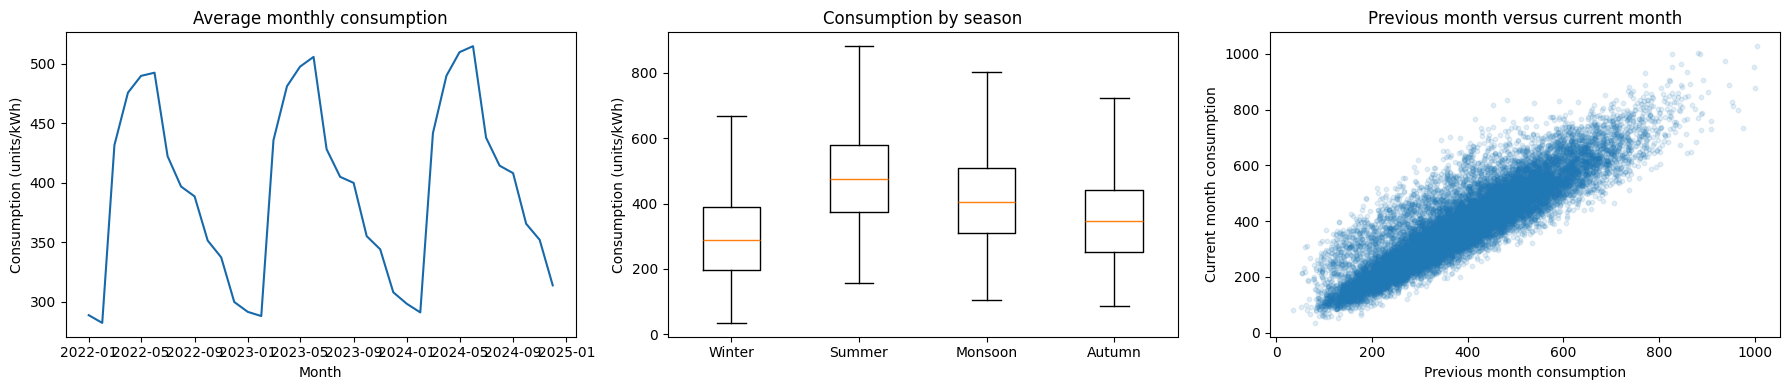

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
monthly_average = df.groupby("month", as_index=False)["monthly_consumption"].mean()
axes[0].plot(monthly_average["month"], monthly_average["monthly_consumption"], color="#1769aa")
axes[0].set_title("Average monthly consumption")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Consumption (units/kWh)")

season_order = [season for season in ["Winter", "Spring", "Summer", "Monsoon", "Autumn"] if season in df["season"].unique()]
axes[1].boxplot(
    [df.loc[df["season"] == season, "monthly_consumption"] for season in season_order],
    labels=season_order,
    showfliers=False,
)
axes[1].set_title("Consumption by season")
axes[1].set_ylabel("Consumption (units/kWh)")

axes[2].scatter(df["previous_month_consumption"], df["monthly_consumption"], alpha=0.12, s=10)
axes[2].set_title("Previous month versus current month")
axes[2].set_xlabel("Previous month consumption")
axes[2].set_ylabel("Current month consumption")
plt.tight_layout()
plt.show()


In [6]:

correlation_columns = numeric_input_columns + ["monthly_consumption"]
display(df[correlation_columns].corr(numeric_only=True)["monthly_consumption"].sort_values(ascending=False).to_frame("correlation_with_target"))


,correlation_with_target
monthly_consumption,1.000000
previous_month_consumption,0.889169
household_size,0.730578
appliance_count,0.695315
number_of_rooms,0.644579
ac_usage_hours,0.513258



## Features, season encoding, and household-level holdout

The target is monthly consumption. Season is categorical and is one-hot encoded. The split is made by household, rather than by random rows, so every test household is unseen during training. This gives a more realistic estimate of performance on new households and prevents months from the same household appearing on both sides of the split.


In [7]:

feature_columns = [
    "household_size", "number_of_rooms", "appliance_count", "ac_usage_hours",
    "season", "previous_month_consumption",
]
target_column = "monthly_consumption"
numeric_features = [
    "household_size", "number_of_rooms", "appliance_count", "ac_usage_hours",
    "previous_month_consumption",
]
categorical_features = ["season"]
X = df[feature_columns].copy()
y = df[target_column].astype(float).copy()
groups = df["household_id"].copy()

household_ids = groups.drop_duplicates().to_numpy()
if len(household_ids) < 5:
    raise ValueError("At least five households are required for grouped five-fold cross-validation.")
train_households, test_households = train_test_split(
    household_ids, test_size=0.20, random_state=RANDOM_SEED
)
train_mask = groups.isin(train_households)
test_mask = groups.isin(test_households)
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
groups_train = groups.loc[train_mask]
print(f"Training households: {len(train_households)} | test households: {len(test_households)}")
print(f"Training rows: {len(X_train):,} | test rows: {len(X_test):,}")


Training households: 400 | test households: 100
Training rows: 14,400 | test rows: 3,600


## Regression models

In [8]:

def make_one_hot_encoder():
    # sparse_output was introduced after sparse in scikit-learn; support both versions.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(polynomial=False):
    if polynomial:
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler()),
        ])
    else:
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("season", categorical_pipeline, categorical_features),
    ])

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", LinearRegression()),
    ]),
    "Polynomial Regression": Pipeline([
        ("preprocessor", make_preprocessor(polynomial=True)),
        ("model", LinearRegression()),
    ]),
    "Decision Tree Regressor": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=3, random_state=RANDOM_SEED)),
    ]),
    "Random Forest Regressor": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=250, min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
        )),
    ]),
    "Gradient Boosting Regressor": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=3,
            min_samples_leaf=3, random_state=RANDOM_SEED
        )),
    ]),
}


## Train, compare, and cross-validate

In [9]:

def regression_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "R2": r2_score(actual, predicted),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": mean_absolute_error(actual, predicted),
    }

fitted_models = {}
test_predictions = {}
test_rows = []
for name, estimator in models.items():
    fitted = clone(estimator)
    fitted.fit(X_train, y_train)
    predicted = fitted.predict(X_test)
    fitted_models[name] = fitted
    test_predictions[name] = predicted
    test_rows.append({"Model": name, **regression_metrics(y_test, predicted)})

test_metrics = pd.DataFrame(test_rows).set_index("Model")
test_metrics.round(3)


,R2,MSE,RMSE,MAE
Model,,,,
Linear Regression,0.914,2086.771,45.681,35.199
Polynomial Regression,0.917,2023.126,44.979,34.772
Decision Tree Regressor,0.904,2345.720,48.433,37.349
Random Forest Regressor,0.911,2153.285,46.404,35.940
Gradient Boosting Regressor,0.916,2041.926,45.188,34.842


In [10]:

# Grouped five-fold CV: each fold holds out complete households.
gkf = GroupKFold(n_splits=5)
cv_rows = []
for name, estimator in models.items():
    for fold, (fold_train, fold_valid) in enumerate(
        gkf.split(X, y, groups=groups), start=1
    ):
        fold_estimator = clone(estimator)
        fold_estimator.fit(X.iloc[fold_train], y.iloc[fold_train])
        fold_predicted = fold_estimator.predict(X.iloc[fold_valid])
        cv_rows.append({
            "Model": name,
            "Fold": fold,
            **regression_metrics(y.iloc[fold_valid], fold_predicted),
        })

cv_fold_metrics = pd.DataFrame(cv_rows)
cv_metrics = (
    cv_fold_metrics.groupby("Model")[["R2", "MSE", "RMSE", "MAE"]]
    .mean()
    .rename(columns=lambda column: f"CV_{column}")
)
metrics_table = test_metrics.join(cv_metrics).sort_values("CV_RMSE")
display(metrics_table.round(3))


,R2,MSE,RMSE,MAE,CV_R2,CV_MSE,CV_RMSE,CV_MAE
Model,,,,,,,,
Polynomial Regression,0.917,2023.126,44.979,34.772,0.914,1908.871,43.672,33.941
Gradient Boosting Regressor,0.916,2041.926,45.188,34.842,0.913,1933.777,43.958,34.133
Linear Regression,0.914,2086.771,45.681,35.199,0.912,1954.558,44.192,34.247
Random Forest Regressor,0.911,2153.285,46.404,35.940,0.907,2066.437,45.451,35.445
Decision Tree Regressor,0.904,2345.720,48.433,37.349,0.899,2236.183,47.275,36.805



The primary selection criterion is the lowest **mean grouped cross-validation RMSE**, because RMSE is in the same units as monthly consumption and grouped folds approximate prediction for unseen households. Test-set RMSE, MAE, and R² are reported alongside it.


In [11]:

best_model_name = metrics_table["CV_RMSE"].idxmin()
best_test_estimator = fitted_models[best_model_name]
best_test_prediction = test_predictions[best_model_name]
best_test_metrics = regression_metrics(y_test, best_test_prediction)
print(f"Selected model: {best_model_name}")
print(f"Grouped CV RMSE: {metrics_table.loc[best_model_name, 'CV_RMSE']:.2f}")
print(f"Held-out household RMSE: {best_test_metrics['RMSE']:.2f}")


Selected model: Polynomial Regression
Grouped CV RMSE: 43.67
Held-out household RMSE: 44.98


## Residual analysis for the selected model

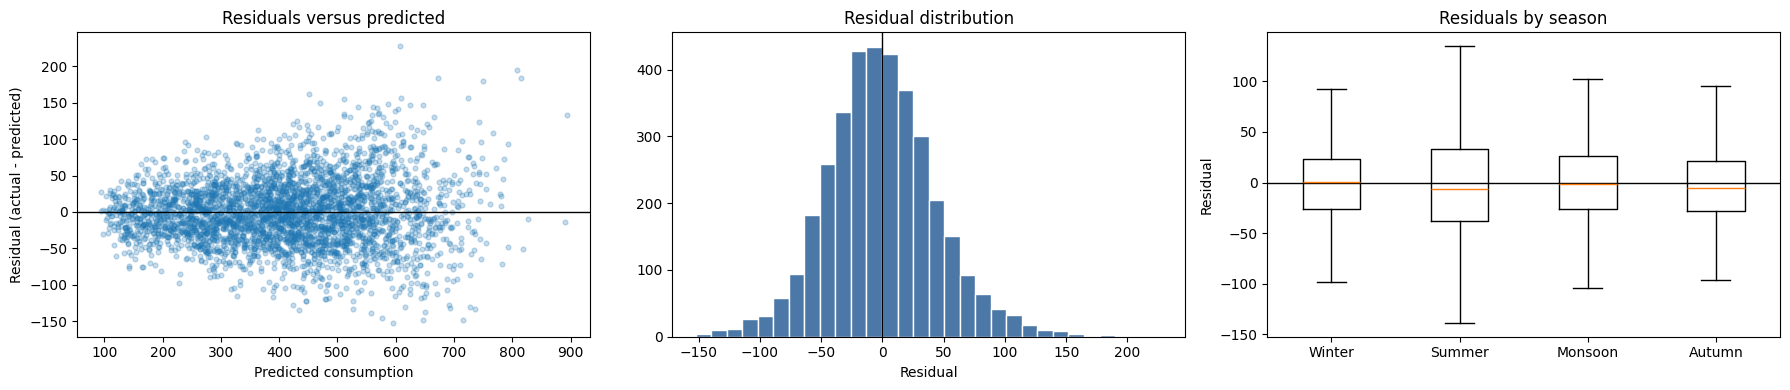

,residual_mean,residual_std,count
prediction_bin,,,
"(93.351, 271.533]",-2.96,30.18,720
"(271.533, 372.874]",-4.65,37.72,720
"(372.874, 451.024]",-0.04,42.75,720
"(451.024, 539.728]",1.22,47.16,720
"(539.728, 893.434]",2.93,60.86,720


Residual/prediction correlation: 0.057


In [12]:

test_evaluation = df.loc[test_mask, ["household_id", "month", "season"]].copy()
test_evaluation["actual"] = y_test.to_numpy()
test_evaluation["predicted"] = best_test_prediction
test_evaluation["residual"] = test_evaluation["actual"] - test_evaluation["predicted"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(test_evaluation["predicted"], test_evaluation["residual"], alpha=0.25, s=12)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals versus predicted")
axes[0].set_xlabel("Predicted consumption")
axes[0].set_ylabel("Residual (actual - predicted)")

axes[1].hist(test_evaluation["residual"], bins=30, color="#4c78a8", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")

axes[2].boxplot(
    [test_evaluation.loc[test_evaluation["season"] == season, "residual"] for season in season_order],
    labels=season_order,
    showfliers=False,
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Residuals by season")
axes[2].set_ylabel("Residual")
plt.tight_layout()
plt.show()

# A useful numerical companion to the residual plot.
test_evaluation["prediction_bin"] = pd.qcut(
    test_evaluation["predicted"], q=5, duplicates="drop"
)
residual_bins = test_evaluation.groupby("prediction_bin", observed=False)["residual"].agg(
    residual_mean="mean", residual_std="std", count="size"
)
display(residual_bins.round(2))
print("Residual/prediction correlation:", round(test_evaluation["predicted"].corr(test_evaluation["residual"]), 3))


## Seasonal performance and influential factors

In [13]:

season_performance = (
    test_evaluation.groupby("season")
    .apply(lambda group: pd.Series({
        "rows": len(group),
        "RMSE": np.sqrt(mean_squared_error(group["actual"], group["predicted"])),
        "MAE": mean_absolute_error(group["actual"], group["predicted"]),
        "actual_mean": group["actual"].mean(),
        "predicted_mean": group["predicted"].mean(),
    }))
    .reindex(season_order)
)
display(season_performance.round(2))


,rows,RMSE,MAE,actual_mean,predicted_mean
season,,,,,
Winter,900.0,37.45,29.34,311.39,311.00
Summer,1200.0,52.70,41.62,491.12,492.40
Monsoon,900.0,43.58,33.51,422.62,423.16
Autumn,600.0,40.40,31.11,364.80,366.23


,feature,absolute coefficient
7,numeric__household_size appliance_count,102.757819
14,numeric__appliance_count^2,73.513204
4,numeric__previous_month_consumption,55.692589
22,season__season_Summer,49.245102
2,numeric__appliance_count,44.628032
3,numeric__ac_usage_hours,41.599508
6,numeric__household_size number_of_rooms,41.258697
19,numeric__previous_month_consumption^2,38.930854
18,numeric__ac_usage_hours previous_month_consump...,29.235512
23,season__season_Winter,28.094524


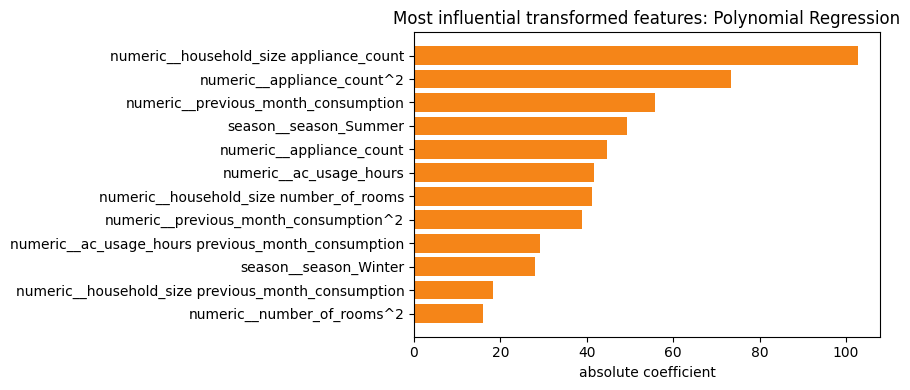

In [14]:

# Use model coefficients or tree importances after preprocessing. For polynomial regression,
# the expanded feature names are shown so the analysis remains transparent.
preprocessor = best_test_estimator.named_steps["preprocessor"]
model_step = best_test_estimator.named_steps["model"]
transformed_names = preprocessor.get_feature_names_out()
if hasattr(model_step, "feature_importances_"):
    influence_values = np.asarray(model_step.feature_importances_)
    influence_label = "importance"
elif hasattr(model_step, "coef_"):
    influence_values = np.abs(np.asarray(model_step.coef_).ravel())
    influence_label = "absolute coefficient"
else:
    influence_values = np.zeros(len(transformed_names))
    influence_label = "importance"

influence = (
    pd.DataFrame({"feature": transformed_names, influence_label: influence_values})
    .sort_values(influence_label, ascending=False)
    .head(12)
)
display(influence)
plt.figure(figsize=(9, 4))
plt.barh(influence["feature"].iloc[::-1], influence[influence_label].iloc[::-1], color="#f58518")
plt.title(f"Most influential transformed features: {best_model_name}")
plt.xlabel(influence_label)
plt.tight_layout()
plt.show()


## Fit the selected model on all available households and save artifacts

In [15]:

# The diagnostic model above was fitted only on the training households. The saved
# deployment pipeline is refitted on every repaired row after model selection.
deployment_model = clone(models[best_model_name])
deployment_model.fit(X, y)
joblib.dump(deployment_model, ARTIFACT_DIR / "best_model.joblib")

metrics_payload = {
    "selected_model": best_model_name,
    "selection_metric": "CV_RMSE",
    "random_seed": RANDOM_SEED,
    "train_households": int(len(train_households)),
    "test_households": int(len(test_households)),
    "rows": int(len(df)),
    "test_metrics": {key: float(value) for key, value in test_metrics.loc[best_model_name].to_dict().items()},
    "all_model_metrics": {
        str(model_name): {key: float(value) for key, value in row.items()}
        for model_name, row in metrics_table.to_dict(orient="index").items()
    },
}
with (ARTIFACT_DIR / "metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(metrics_payload, handle, indent=2)

feature_config = {
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_column": target_column,
    "season_options": season_order,
    "random_seed": RANDOM_SEED,
    "prediction_unit": "monthly units/kWh as defined by the generated panel",
}
with (ARTIFACT_DIR / "feature_config.json").open("w", encoding="utf-8") as handle:
    json.dump(feature_config, handle, indent=2)

print("Saved:")
for artifact in ["best_model.joblib", "metrics.json", "feature_config.json"]:
    print(" -", ARTIFACT_DIR / artifact)


Saved:
 - artifacts/best_model.joblib
 - artifacts/metrics.json
 - artifacts/feature_config.json



## Answers to the case-study questions

- **Can household consumption be predicted from household attributes?** Yes. The held-out household metrics above quantify how well the selected model generalises. The remaining error reflects unobserved behaviour and weather.
- **Which factor has the greatest effect?** The influence chart ranks the transformed features for the selected model. In this synthetic design, previous consumption and AC usage/season are expected to be prominent; the chart is the evidence for this run.
- **Is seasonal variation captured?** The season feature is one-hot encoded and the seasonal table compares actual and predicted means and RMSE. Similar actual and predicted seasonal means indicate that the broad seasonal pattern is being learned.
- **Does the residual plot show constant variance?** A roughly even residual spread around zero and similar residual standard deviations across prediction bins support constant variance. A widening funnel or strong residual correlation indicates heteroscedasticity; inspect the residual plots and table rather than assuming it away.
- **Which algorithm achieves the lowest RMSE?** The selected row is the model with the lowest grouped five-fold `CV_RMSE`; the complete comparison table reports held-out RMSE for all five required algorithms.
- **How well does the model perform on new households?** The household-level holdout and grouped five-fold results are the relevant estimates. RMSE is expressed in the same units as monthly consumption, so it can be read as a typical planning error.
- **Can the model be deployed for demand forecasting?** Yes, as a lightweight planning aid. The saved pipeline and metrics are used by the Streamlit application. For operational forecasting, the model should be retrained with weather, tariff, occupancy, holidays, solar generation, and meter-quality signals, and monitored for drift.

### Limitations

The panel is synthetic because no public data set contains every requested household attribute. Its relationships are plausible assumptions rather than measured causal effects. The model has no temperature, humidity, tariff, occupancy schedule, appliance power rating, outages, or distributed-generation inputs. Therefore, predictions are useful for demonstrating the workflow and supporting approximate planning, but they should not be treated as a utility-grade load forecast without real meter and weather validation.
